In [7]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

In [8]:
# ============================================================
# 2. CARREGANDO MODELOS
# ============================================================

models_path = "../models"

model_files = {
    "Logistic Regression Baseline":
        "logistic_regression_pipeline.pkl",

    "Logistic Regression Tuned":
        "logistic_regression_tuned_pipeline.pkl",

    "XGBoost Baseline":
        "xgboost_baseline_pipeline.pkl",

    "XGBoost Tuned":
        "xgboost_tuned_pipeline.pkl",
}

models = {}

for model_name, filename in model_files.items():

    path = os.path.join(models_path, filename)

    models[model_name] = joblib.load(path)

    print(f"{model_name} carregado.")

Logistic Regression Baseline carregado.
Logistic Regression Tuned carregado.
XGBoost Baseline carregado.
XGBoost Tuned carregado.


In [12]:
# ==================================================
# Leitura dos dados
# ==================================================

TARGET = "default payment next month"

df = pd.read_excel(
    r"C:\Users\T-Gamer\Desktop\igor\credit-default-api\data\raw\default_of_credit_card_clients.xls",
    header=1
)

# ============================================================
# 3. SEPARAÇÃO ENTRE FEATURES E TARGET
# ============================================================

X = df.drop(columns=["ID", TARGET])

y = df[TARGET]

print("=" * 60)
print("Dataset")
print("=" * 60)

print(f"Número de observações : {df.shape[0]}")
print(f"Número de variáveis   : {X.shape[1]}")

# ============================================================
# 4. SEPARAÇÃO TREINO / TESTE
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTreino:", X_train.shape)
print("Teste :", X_test.shape)

Dataset
Número de observações : 30000
Número de variáveis   : 23

Treino: (24000, 23)
Teste : (6000, 23)


In [13]:
# ============================================================
# 3. VERIFICANDO DADOS DE TESTE
# ============================================================

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (6000, 23)
y_test: (6000,)


In [14]:
# ============================================================
# 4. FUNÇÃO DE AVALIAÇÃO
# ============================================================

def evaluate_model(model, X_test, y_test, threshold=0.5):

    # Probabilidade da classe positiva
    y_proba = model.predict_proba(X_test)[:, 1]

    # Classificação utilizando o threshold informado
    y_pred = (y_proba >= threshold).astype(int)

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc
    }

In [15]:
# ============================================================
# 5. COMPARAÇÃO GERAL DOS MODELOS
# ============================================================

results = []

for model_name, model in models.items():

    metrics = evaluate_model(
        model,
        X_test,
        y_test,
        threshold=0.5
    )

    metrics["Modelo"] = model_name

    results.append(metrics)


comparison = pd.DataFrame(results)

comparison = comparison[
    [
        "Modelo",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC AUC",
        "PR AUC"
    ]
]

comparison = comparison.sort_values(
    by="ROC AUC",
    ascending=False
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Modelo,Accuracy,Precision,Recall,F1-score,ROC AUC,PR AUC
0,XGBoost Tuned,0.817333,0.661992,0.355690,0.462745,0.777015,0.551837
1,XGBoost Baseline,0.818333,0.662551,0.363979,0.469844,0.773073,0.548840
2,Logistic Regression Tuned,0.678000,0.367499,0.632253,0.464820,0.710543,0.491112
3,Logistic Regression Baseline,0.809500,0.696581,0.245667,0.363231,0.709954,0.494866


In [16]:
# ============================================================
# 6. RANKING POR ROC AUC
# ============================================================

ranking_auc = comparison[
    ["Modelo", "ROC AUC", "PR AUC"]
].copy()

ranking_auc

,Modelo,ROC AUC,PR AUC
0,XGBoost Tuned,0.777015,0.551837
1,XGBoost Baseline,0.773073,0.548840
2,Logistic Regression Tuned,0.710543,0.491112
3,Logistic Regression Baseline,0.709954,0.494866


In [17]:
# ============================================================
# 7. PRECISION x RECALL x F1
# ============================================================

metrics_comparison = comparison[
    [
        "Modelo",
        "Precision",
        "Recall",
        "F1-score"
    ]
]

metrics_comparison

,Modelo,Precision,Recall,F1-score
0,XGBoost Tuned,0.661992,0.355690,0.462745
1,XGBoost Baseline,0.662551,0.363979,0.469844
2,Logistic Regression Tuned,0.367499,0.632253,0.464820
3,Logistic Regression Baseline,0.696581,0.245667,0.363231


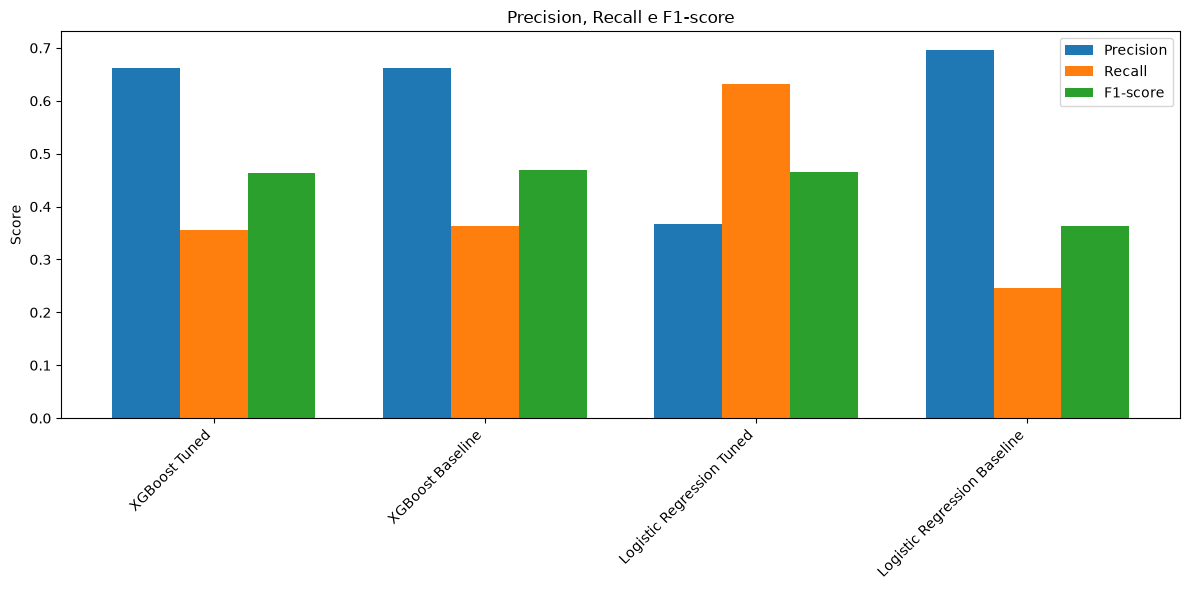

In [18]:
plt.figure(figsize=(12, 6))

x = np.arange(len(comparison))
width = 0.25

plt.bar(
    x - width,
    comparison["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x,
    comparison["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + width,
    comparison["F1-score"],
    width,
    label="F1-score"
)

plt.xticks(
    x,
    comparison["Modelo"],
    rotation=45,
    ha="right"
)

plt.ylabel("Score")
plt.title("Precision, Recall e F1-score")

plt.legend()

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# 8. MATRIZES DE CONFUSÃO
# ============================================================

confusion_results = []

for model_name, model in models.items():

    y_proba = model.predict_proba(X_test)[:, 1]

    y_pred = (y_proba >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    confusion_results.append({
        "Modelo": model_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })


confusion_df = pd.DataFrame(confusion_results)

confusion_df

,Modelo,TN,FP,FN,TP
0,Logistic Regression Baseline,4531,142,1001,326
1,Logistic Regression Tuned,3229,1444,488,839
2,XGBoost Baseline,4427,246,844,483
3,XGBoost Tuned,4432,241,855,472


In [21]:
# ============================================================
# 10. ANÁLISE DE THRESHOLD
# ============================================================

def threshold_analysis(model, X_test, y_test):

    y_proba = model.predict_proba(X_test)[:, 1]

    thresholds = np.arange(
        0.10,
        0.91,
        0.05
    )

    results = []

    for threshold in thresholds:

        y_pred = (
            y_proba >= threshold
        ).astype(int)

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        results.append({
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1
        })

    return pd.DataFrame(results)

In [22]:
# ============================================================
# 11. THRESHOLD - XGBOOST TUNED
# ============================================================

xgb_thresholds = threshold_analysis(
    models["XGBoost Tuned"],
    X_test,
    y_test
)

xgb_thresholds

,Threshold,Precision,Recall,F1-score
0,0.10,0.280734,0.910324,0.429130
1,0.15,0.351462,0.779201,0.484423
2,0.20,0.434197,0.656368,0.522652
3,0.25,0.502554,0.593067,0.544072
4,0.30,0.537538,0.539563,0.538548
5,0.35,0.577758,0.481537,0.525277
6,0.40,0.611940,0.432555,0.506843
7,0.45,0.635018,0.388093,0.481759
8,0.50,0.661992,0.355690,0.462745
9,0.55,0.681319,0.327054,0.441955


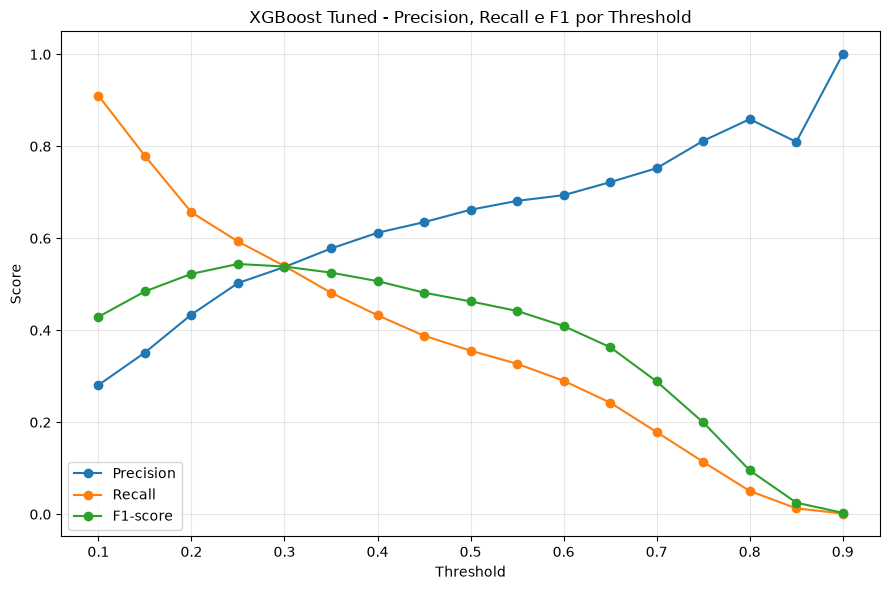

In [23]:
# ============================================================
# 12. PRECISION x RECALL POR THRESHOLD
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    xgb_thresholds["Threshold"],
    xgb_thresholds["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    xgb_thresholds["Threshold"],
    xgb_thresholds["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    xgb_thresholds["Threshold"],
    xgb_thresholds["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title(
    "XGBoost Tuned - Precision, Recall e F1 por Threshold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 13. MELHOR THRESHOLD POR F1
# ============================================================

best_threshold_f1 = xgb_thresholds.loc[
    xgb_thresholds["F1-score"].idxmax()
]

best_threshold_f1

Threshold    0.250000
Precision    0.502554
Recall       0.593067
F1-score     0.544072
Name: 3, dtype: float64

In [25]:
# ============================================================
# 14. THRESHOLDS COM RECALL >= 0.50
# ============================================================

recall_50 = xgb_thresholds[
    xgb_thresholds["Recall"] >= 0.50
].copy()

recall_50

,Threshold,Precision,Recall,F1-score
0,0.10,0.280734,0.910324,0.429130
1,0.15,0.351462,0.779201,0.484423
2,0.20,0.434197,0.656368,0.522652
3,0.25,0.502554,0.593067,0.544072
4,0.30,0.537538,0.539563,0.538548


In [26]:
# ============================================================
# 15. THRESHOLDS COM RECALL >= 0.60
# ============================================================

recall_60 = xgb_thresholds[
    xgb_thresholds["Recall"] >= 0.60
].copy()

recall_60

,Threshold,Precision,Recall,F1-score
0,0.10,0.280734,0.910324,0.429130
1,0.15,0.351462,0.779201,0.484423
2,0.20,0.434197,0.656368,0.522652


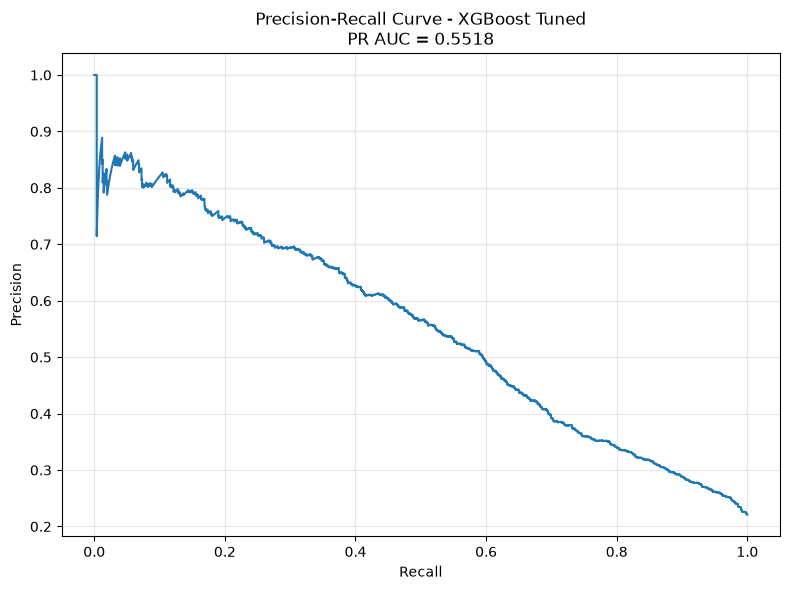

In [27]:
# ============================================================
# 16. CURVA PRECISION-RECALL - XGBOOST TUNED
# ============================================================

xgb_tuned = models["XGBoost Tuned"]

y_proba_xgb = xgb_tuned.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba_xgb
)

pr_auc = average_precision_score(
    y_test,
    y_proba_xgb
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    f"Precision-Recall Curve - XGBoost Tuned\n"
    f"PR AUC = {pr_auc:.4f}"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# 17. COMPARAÇÃO DE THRESHOLDS
# ============================================================

candidate_models = {
    "Logistic Regression Tuned":
        models["Logistic Regression Tuned"],

    "XGBoost Tuned":
        models["XGBoost Tuned"]
}

threshold_comparison = []

for model_name, model in candidate_models.items():

    threshold_results = threshold_analysis(
        model,
        X_test,
        y_test
    )

    threshold_results["Modelo"] = model_name

    threshold_comparison.append(
        threshold_results
    )


threshold_comparison = pd.concat(
    threshold_comparison,
    ignore_index=True
)

threshold_comparison

,Threshold,Precision,Recall,F1-score,Modelo
0,0.10,0.223442,0.996986,0.365066,Logistic Regression Tuned
1,0.15,0.225534,0.986436,0.367129,Logistic Regression Tuned
2,0.20,0.231945,0.948757,0.372761,Logistic Regression Tuned
3,0.25,0.238400,0.925396,0.379129,Logistic Regression Tuned
4,0.30,0.245570,0.887717,0.384716,Logistic Regression Tuned
5,0.35,0.258329,0.829691,0.393988,Logistic Regression Tuned
6,0.40,0.277183,0.779955,0.409010,Logistic Regression Tuned
7,0.45,0.302043,0.712886,0.424310,Logistic Regression Tuned
8,0.50,0.367499,0.632253,0.464820,Logistic Regression Tuned
9,0.55,0.469443,0.526752,0.496449,Logistic Regression Tuned


In [29]:
# ============================================================
# 18. MELHOR F1 POR MODELO
# ============================================================

best_thresholds = (
    threshold_comparison
    .loc[
        threshold_comparison
        .groupby("Modelo")["F1-score"]
        .idxmax()
    ]
    .sort_values(
        "F1-score",
        ascending=False
    )
)

best_thresholds

,Threshold,Precision,Recall,F1-score,Modelo
20,0.25,0.502554,0.593067,0.544072,XGBoost Tuned
9,0.55,0.469443,0.526752,0.496449,Logistic Regression Tuned


In [30]:
# ============================================================
# 19. RANKING FINAL PRELIMINAR
# ============================================================

final_comparison = comparison.copy()

final_comparison[
    "F1 Rank"
] = final_comparison[
    "F1-score"
].rank(
    ascending=False,
    method="min"
)

final_comparison[
    "ROC AUC Rank"
] = final_comparison[
    "ROC AUC"
].rank(
    ascending=False,
    method="min"
)

final_comparison[
    "PR AUC Rank"
] = final_comparison[
    "PR AUC"
].rank(
    ascending=False,
    method="min"
)

final_comparison.sort_values(
    "ROC AUC",
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1-score,ROC AUC,PR AUC,F1 Rank,ROC AUC Rank,PR AUC Rank
0,XGBoost Tuned,0.817333,0.661992,0.355690,0.462745,0.777015,0.551837,3.0,1.0,1.0
1,XGBoost Baseline,0.818333,0.662551,0.363979,0.469844,0.773073,0.548840,1.0,2.0,2.0
2,Logistic Regression Tuned,0.678000,0.367499,0.632253,0.464820,0.710543,0.491112,2.0,3.0,4.0
3,Logistic Regression Baseline,0.809500,0.696581,0.245667,0.363231,0.709954,0.494866,4.0,4.0,3.0
